## Boiler plate code - just run once quickly

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from toksearch_d3d import PtDataSignal

  The MDSplus python module version (HEAD_release_7.139.59) does not match
  the version of the installed MDSplus libraries (unknown_release_0.0.0).
  Upgrade the module using the mdsplus/python/MDSplus directory of the
  MDSplus installation or set PYTHONPATH=/usr/local/mdsplus/python.


#### Load pre-defined targets

In [5]:
import os
from pathlib import Path

# os.environ["HOME"]

base = Path(os.path.join(os.environ["HOME"], "rl_prof_control_exp/final_lp_targets"))
num_total_targets = 15

rot_rows = []
dens_rows = []
etemp_rows = []
pres_rows = []

for i in range(num_total_targets):
    path = base / f"T{i+1}.txt"
    data = np.loadtxt(path, skiprows=2)  # 4 rows x 33 cols
    rot_rows.append(data[0])
    dens_rows.append(data[1])
    etemp_rows.append(data[2])
    pres_rows.append(data[3])

rot_targets = np.stack(rot_rows)    # shape (num_total_targets, 33)
dens_targets = np.stack(dens_rows)  # shape (num_total_targets, 33)
etemp_targets = np.stack(etemp_rows)
pres_targets = np.stack(pres_rows)

rot_targets.shape, dens_targets.shape, etemp_targets.shape, pres_targets.shape

((15, 33), (15, 33), (15, 33), (15, 33))

#### Helper functions

In [6]:
def big_print(text, size=24):
    from IPython.display import display, HTML
    display(HTML(f"<div style='font-size:{size}px'>{text}</div>"))

def filter_lp(x, prev_y, dt, tau):
    """
    Low-pass filter function.
    
    Args:
        x: Current input value
        prev_y: Previous filtered output value
        dt: Time step
        tau: Time constant (filter strength)
    
    Returns:
        Filtered output value
    """
    return prev_y + dt / (dt + tau) * (x - prev_y)

def apply_lp_filter(data, dt, tau):
    """
    Apply low-pass filter to an array of data.
    
    Args:
        data: Input data array
        dt: Time step (or can be an array of time differences)
        tau: Time constant (controls filter strength)
    
    Returns:
        Filtered data array
    """
    filtered = np.zeros_like(data)
    filtered[0] = data[0]  # Initialize with first value
    
    for i in range(1, len(data)):
        filtered[i] = filter_lp(data[i], filtered[i-1], dt, tau)
    
    return filtered




In [7]:
def interp_full(psi_in, values_in, psi_out):
    """
    Full interpolation function that interpolates from (psi_in, values_in) to psi_out.
    
    Args:
        psi_in: Input psi coordinates (array)
        values_in: Input values at psi_in coordinates (array)
        psi_out: Output psi coordinates where interpolation is desired (array)
    
    Returns:
        Interpolated values at psi_out coordinates
    """
    in_size = len(psi_in)
    out_size = len(psi_out)
    out = np.zeros(out_size)
    
    # Find min and max indices
    j_min = [0, 0]
    j_max = [0, 0]
    
    # Find absolute min and max
    j_min[0] = np.argmin(psi_in)
    j_max[0] = np.argmax(psi_in)
    
    # Find second smallest and second largest
    j_min[1] = j_max[0]
    j_max[1] = j_min[0]
    
    for j in range(in_size):
        if psi_in[j] > psi_in[j_min[0]] and psi_in[j] <= psi_in[j_min[1]]:
            j_min[1] = j
        if psi_in[j] < psi_in[j_max[0]] and psi_in[j] >= psi_in[j_max[1]]:
            j_max[1] = j
    
    # Interpolate for each output point
    for i in range(out_size):
        psi_t = psi_out[i]
        j_high = j_max[0]
        j_low = j_min[0]
        
        # Find bracketing indices
        for j in range(in_size):
            if psi_in[j] > psi_t and psi_in[j] < psi_in[j_high]:
                j_high = j
            elif psi_in[j] < psi_t and psi_in[j] > psi_in[j_low]:
                j_low = j
        
        # Handle extrapolation at boundaries
        if j_high == j_max[0]:
            j_low = j_max[1]
        elif j_low == j_min[0]:
            j_high = j_min[1]
        
        # Linear interpolation
        out_high = values_in[j_high]
        out_low = values_in[j_low]
        psi_n_diff = psi_in[j_high] - psi_in[j_low]
        weight = (psi_t - psi_in[j_low]) / psi_n_diff if abs(psi_n_diff) >= 1e-5 else 0.0
        out[i] = out_low + weight * (out_high - out_low)
    
    return out


def interp_profile(values_in, out_size):
    """
    Interpolate profile from input size to output size using uniform psi grid.
    
    Args:
        values_in: Input profile values (array of length in_size)
        out_size: Desired output size (e.g., 33)
    
    Returns:
        Interpolated profile of length out_size
    """
    in_size = len(values_in)
    
    # Create uniform psi grids
    psi_in = np.linspace(0, 1, in_size)
    psi_out = np.linspace(0, 1, out_size)
    
    return interp_full(psi_in, values_in, psi_out)


def convert_profiles_101_to_33(profiles_101):
    """
    Convert profiles from 101 dimensions to 33 dimensions.
    
    Args:
        profiles_101: Array of shape (..., 101) with profiles to convert
    
    Returns:
        Array of shape (..., 33) with interpolated profiles
    """
    original_shape = profiles_101.shape
    
    # Reshape to (N, 101) where N is product of all dimensions except last
    profiles_flat = profiles_101.reshape(-1, original_shape[-1])
    
    # Interpolate each profile
    profiles_33 = np.array([interp_profile(prof, 33) for prof in profiles_flat])
    
    # Reshape back to original dimensions with 33 instead of 101
    new_shape = original_shape[:-1] + (33,)
    return profiles_33.reshape(new_shape)

In [8]:
# rot_targets.shape


# Set Shot Data

In [9]:
###
# 206586 , etemp, [6,10,5,6], [1500, 2500, 3500, 4500, 5000]
# 206587 , etemp, [10,7,7,10], [1500, 2500, 3500, 4500, 5000]
# 206588 , etemp, [10,13,13,10], [1500, 2500, 3500, 4000, 5000]
# 206589 , etemp, [7,4,4,7] [1500, 2500, 3500, 4500, 5000]

# 206590 , rot, [12,7,7,12] [1500, 2500, 3500, 4000, 5000]
# 206591 , rot, [12,7,7,12] [1500, 2500, 3500, 4000, 5000]

# 206592, pres [11,6,6,11]
# 206593, pres [11,6,6,11]
# 206594, pres [4,7,7,4]
# 206595, pres [7,4,4,7]
# 206596, pres [7,4,4,7]


In [10]:
## FILL THIS CELL###


shot = 206586
prof_type = 'etemp'  # ['rot', 'dens', 'pres', 'etemp']

#idxs should be between 1 and 15 (inclusive)
true_target_indxs = [6, 10, 5, 6]  # idices of selected targets
selected_target_idxs = [i-1 for i in true_target_indxs]  # idices of selected targets
targets_set_time = [1500, 2500, 3500, 4000, 5000]  # [start flattop time/target1 start_t, target2 start_t, target3 start_t, end flattop time]


tau = 20
rad_idxs_to_analyze = [0, 5, 10, 15, 20, 25, 30]  # radius positions to examine

In [11]:
assert len(selected_target_idxs) == len(targets_set_time) - 1, "Number of target indices must be one less than number of target set times."
assert prof_type in ['rot', 'dens', 'pres', 'etemp'], "Profile type must be one of ['rot', 'dens', 'pres', 'etemp']."
print("================= Metadata =================")
print(f"Shot ID: {shot}")
print(f"Profile for analysis: {prof_type}")
print(f"Raidus indices to analyze: {len(rad_idxs_to_analyze)} positions: {rad_idxs_to_analyze}")
for i in range(len(selected_target_idxs)):
    print(f"Target {i+1}: index {selected_target_idxs[i]}, effective from {targets_set_time[i]} to {targets_set_time[i+1]} ms")
print("============================================")

if prof_type == 'rot':
    all_targets = rot_targets
elif prof_type == 'dens':
    all_targets = dens_targets
elif prof_type == 'etemp':
    all_targets = etemp_targets
elif prof_type == 'pres':
    all_targets = pres_targets

================= Metadata =================
Shot ID: 206586
Profile for analysis: etemp
Raidus indices to analyze: 7 positions: [0, 5, 10, 15, 20, 25, 30]
Target 1: index 5, effective from 1500 to 2500 ms
Target 2: index 9, effective from 2500 to 3500 ms
Target 3: index 4, effective from 3500 to 4000 ms
Target 4: index 5, effective from 4000 to 5000 ms


In [12]:
pres_targets[6]

array([82.6 , 82.5 , 81.72, 80.21, 78.1 , 75.66, 73.07, 70.3 , 67.36,
       64.33, 61.26, 58.22, 55.28, 52.54, 49.99, 47.57, 45.19, 42.9 ,
       40.58, 38.22, 35.92, 33.71, 31.58, 29.51, 27.53, 25.48, 23.1 ,
       20.77, 18.57, 16.73, 15.01, 12.22,  9.11])

#### Pull RTCAKENN data

In [13]:
x = PtDataSignal('CKXOUT').fetch(shot)
times = x['times']
data = x['data']
NYMODEL = 2
NYOUT_PTS = 101
NYPROF = 7
prof_data = data.reshape((-1, NYMODEL, NYOUT_PTS, NYPROF))
dens_profiles = prof_data[:, 1, :, 3]  # 3-- for density || 6 for rotation
rot_profiles = prof_data[:, 1, :, 6]
# q_profiles = prof_data[:, 1, :, 2]
pres_profiles = prof_data[:, 1, :, 0]
etemp_profiles = prof_data[:, 1, :, 4]

# down-sampling
dens_profiles_33 = convert_profiles_101_to_33(dens_profiles)
rot_profiles_33 = convert_profiles_101_to_33(rot_profiles)
# q_profiles_33 = convert_profiles_101_to_33(q_profiles)
pres_profiles_33 = convert_profiles_101_to_33(pres_profiles)
etemp_profiles_33 = convert_profiles_101_to_33(etemp_profiles)

#smoothening with low-pass filter
rot_profiles_33 = apply_lp_filter(rot_profiles_33, dt=20.0, tau=tau)
dens_profiles_33 = apply_lp_filter(dens_profiles_33, dt=20.0, tau=tau)
pres_profiles_33 = apply_lp_filter(pres_profiles_33, dt=20.0, tau=tau)
etemp_profiles_33 = apply_lp_filter(etemp_profiles_33, dt=20.0, tau=tau)

print(dens_profiles_33.shape, rot_profiles_33.shape, pres_profiles_33.shape, etemp_profiles_33.shape)

if prof_type == 'rot':
    profile_signals = rot_profiles_33
elif prof_type == 'dens':
    profile_signals = dens_profiles_33
elif prof_type == 'pres':
    profile_signals = pres_profiles_33
elif prof_type == 'etemp':
    profile_signals = etemp_profiles_33

Environment variable TOKSEARCH_INDEX_DIR not set.
Environment variable TOKSEARCH_INDEX_DIR not set.
Environment variable TOKSEARCH_INDEX_DIR not set.
Environment variable TOKSEARCH_INDEX_DIR not set.


(355, 33) (355, 33) (355, 33) (355, 33)


#### Comparing data and targets

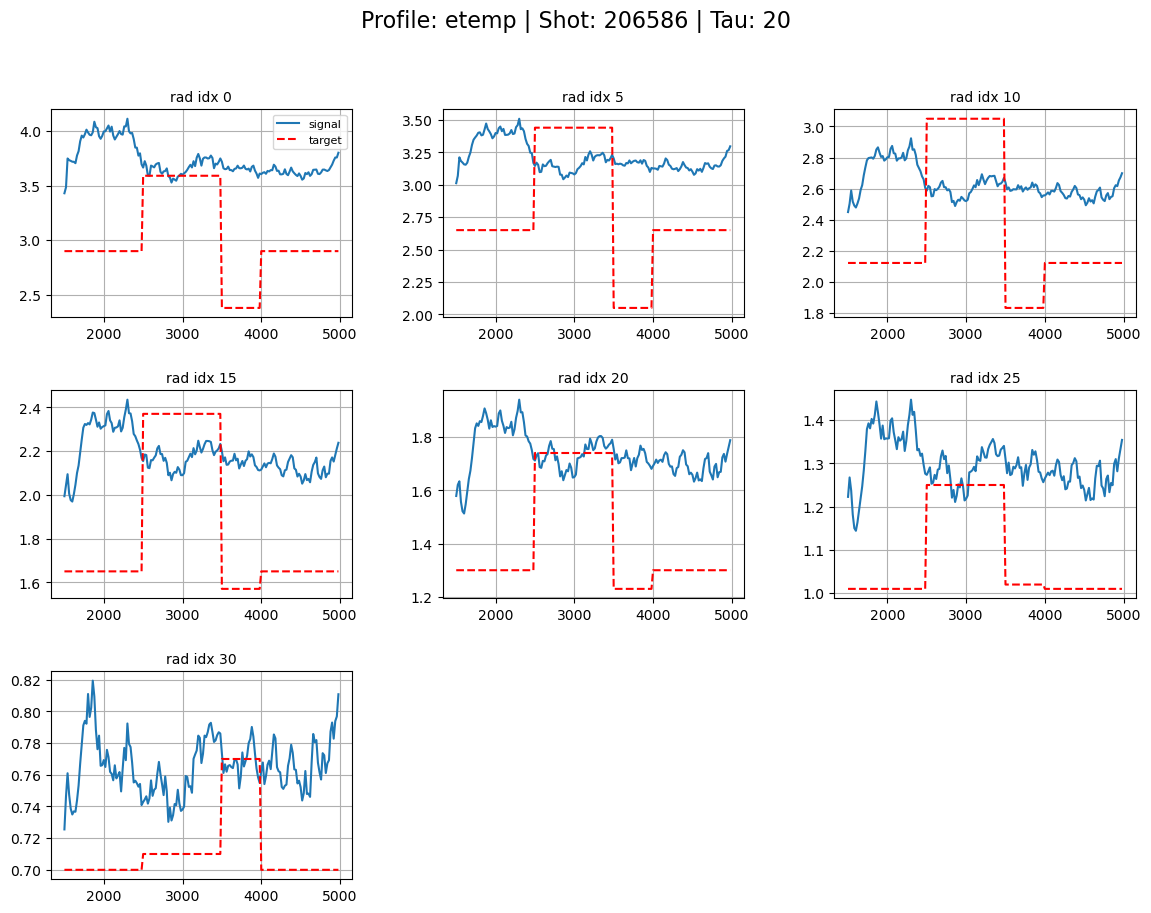

In [14]:
num_set_targets = len(selected_target_idxs)
set_time_idxs = [np.argmin(np.abs(times - t)) for t in targets_set_time]
# use real time values (ms) for x axis
x_times = times[set_time_idxs[0]:set_time_idxs[-1]]
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.ravel()
for i in range(len(rad_idxs_to_analyze)):
    ax = axes[i]
    ax.plot(x_times, profile_signals[set_time_idxs[0]:set_time_idxs[-1], rad_idxs_to_analyze[i]], label='signal')
    yi = np.empty(x_times.size, dtype=float)
    start_idx = 0
    for j in range(num_set_targets):
        seg_len = set_time_idxs[j+1] - set_time_idxs[0]
        yi[start_idx:seg_len] = all_targets[selected_target_idxs[j], rad_idxs_to_analyze[i]]
        start_idx = seg_len
    ax.plot(x_times, yi, label='target', linestyle='--', color='r')
    ax.set_title(f"rad idx {rad_idxs_to_analyze[i]}", fontsize=10)
    ax.grid(True)
    if i == 0:
        ax.legend(fontsize=8)

# hide any unused subplots
for k in range(len(rad_idxs_to_analyze), len(axes)):
    axes[k].axis('off')

plt.suptitle(f"Profile: {prof_type} | Shot: {shot} | Tau: {tau}", fontsize=16)
fig.subplots_adjust(hspace=0.35, wspace=0.3)
# set xlabel on bottom-center subplot
# axes[7].set_xlabel("Time (ms)")
plt.show()


In [33]:
# plot the actuators
import MDSplus
from gadata import gadata

signals = ['bmspinj30l', 'bmspinj30r', 'bmspinj33l', 'bmspinj33r', 'bmspinj15l', 'bmspinj15r', 'bmspinj21l', 'bmspinj21r','gasA','echpwrc']
on_axis_beams = ['bmspinj30l', 'bmspinj30r','bmspinj33l', 'bmspinj33r']
off_axis_beams = ['bmspinj15l', 'bmspinj15r','bmspinj21l', 'bmspinj21r']

conn2 = MDSplus.Connection('atlas.gat.com')

act_data = {}
on_axis_pwr = None
off_axis_pwr = None
for signal in signals:
    data = gadata(signal, shot, connection=conn2)
    x = np.asarray(data.xdata)
    y = np.asarray(data.zdata)

    #sample to every 20ms
    x = x[::20]
    y = y[::20]
    #smooth with low-pass filter
    y = apply_lp_filter(y, dt=20.0, tau=1500)
    act_data[signal] = y
    act_data[signal+'_time'] = x

    if signal in on_axis_beams:
        if on_axis_pwr is None:
            on_axis_pwr = y
            act_data['on_axis_pwr_time'] = x
        else:
            on_axis_pwr += y
    elif signal in off_axis_beams:
        if off_axis_pwr is None:
            off_axis_pwr = y
            act_data['off_axis_pwr_time'] = x
        else:
            off_axis_pwr += y
    else:
        pass
    
    act_data['on_axis_pwr'] = on_axis_pwr
    act_data['off_axis_pwr'] = off_axis_pwr

# act_data

   bmspinj30l fetched from PTDATA in 2.09s
   bmspinj30r fetched from PTDATA in 0.07s
   bmspinj33l fetched from PTDATA in 0.07s
   bmspinj33r fetched from PTDATA in 0.07s
   bmspinj15l fetched from PTDATA in 0.07s
   bmspinj15r fetched from PTDATA in 0.07s
   bmspinj21l fetched from PTDATA in 0.07s
   bmspinj21r fetched from PTDATA in 0.07s
   gasA fetched from PTDATA in 1.05s
   echpwrc fetched from MDSplus tree RF in 0.02s


In [32]:
# act_data['bmspinj30l_time'], act_data['gasA_time']

Text(0.5, 0.98, 'Actuator Signals | Shot: 206586 | Tau: 1500')

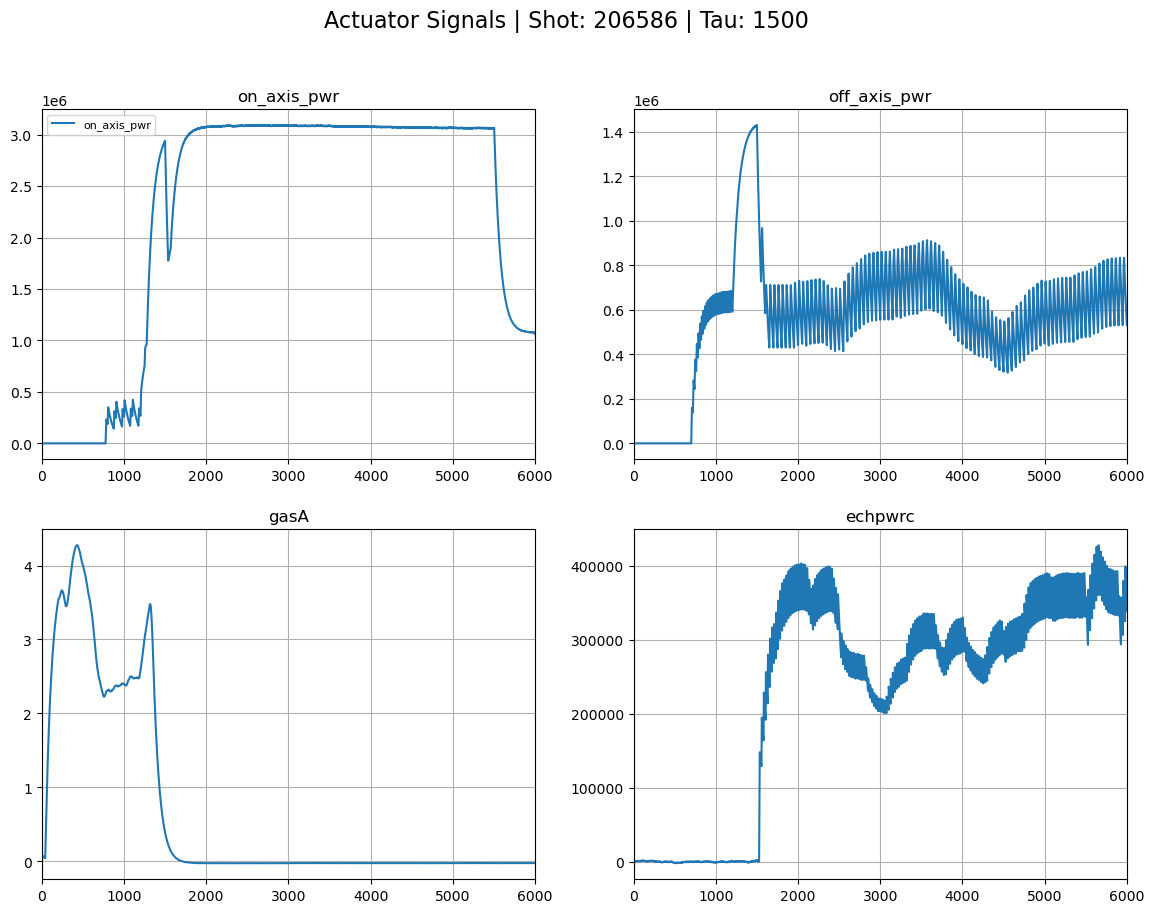

In [36]:
# plot a 2x2 grid of the actuators
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()


for i, signal in enumerate(['on_axis_pwr', 'off_axis_pwr', 'gasA', 'echpwrc']):
    if signal in act_data:
        axes[i].plot(act_data[signal+'_time'], act_data[signal], label=signal)
        axes[i].set_title(signal)
        axes[i].grid(True)
        axes[i].set_xlim(0, 6000)
        if i == 0:
            axes[i].legend(fontsize=8)
plt.suptitle(f"Actuator Signals | Shot: {shot} | Tau: 1500", fontsize=16)

In [16]:
## FULL PROFILE PLOTS -- COMMENTED OUT FOR NOW


## plot the profile values at different times
# times = np.arange(targets_set_time[0]-500, targets_set_time[-1]+500, 100)  # from 500ms before first target to 500ms after last target, every 100ms


# plot_times = np.arange(1500, 5000, 200)
# print(len(plot_times))
# fig, axes = plt.subplots(4, 5, figsize=(14, 13), sharex=False, sharey=False)

# for i in range(len(plot_times)):
#     ax = axes[i//5, i%5]
#     time_idx = np.argmin(np.abs(plot_times[i] - x['times']))
#     ax.plot(profile_signals[time_idx], label=f't={plot_times[i]}ms')
    
#     # display the corresponding target profile as dashed red line, if within the target set time range
#     if plot_times[i] >= targets_set_time[0] and plot_times[i] <= targets_set_time[-1]:
#         target_idx = None
#         for j in range(num_set_targets):
#             if plot_times[i] >= targets_set_time[j] and plot_times[i] < targets_set_time[j+1]:
#                 target_idx = selected_target_idxs[j]
#                 break
#         if target_idx is not None:
#             ax.plot(all_targets[target_idx], label=f'target idx {target_idx}', linestyle='--', color='r')

#     ax.set_title(f"t={plot_times[i]}ms", fontsize=10)
#     ax.grid(True)
#     if i == 0:
#         ax.legend(fontsize=8)

# plt.suptitle(f"Profile: {prof_type} | Shot: {shot}",fontsize=16)

## Basic Selection Code

Text(0.5, 1.0, '15 targets to pres t=2000ms')

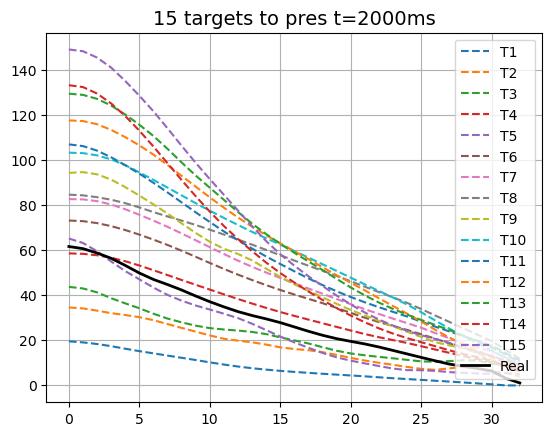

In [37]:
ref_time = 2000

n_closest = 15 #max 15

ref_time_idx = np.argmin(np.abs(times - ref_time))  # find the index closest to ref_time
# prof33_at_ref_time = convert_profiles_101_to_33(profile_signals[ref_time_idx, :])
prof33_at_ref_time = profile_signals[ref_time_idx,:]

#plot n closest profiles based on 0th index
diffs = np.linalg.norm(all_targets - prof33_at_ref_time, axis=1)
ref_target_candidates_idxs = np.argsort(diffs)[:n_closest]

#sort the indices based on their number
ref_target_candidates_idxs = np.sort(ref_target_candidates_idxs)

for idx in ref_target_candidates_idxs:
    plt.plot(all_targets[idx], label=f'T{idx+1}', linestyle='--')

plt.plot(prof33_at_ref_time, label=f'Real', color='k', linewidth=2)
plt.legend()
plt.grid()
plt.title(f"{n_closest} targets to {prof_type} t={ref_time}ms", fontsize=14)

NameError: name 'prof33_at_ref_time' is not defined

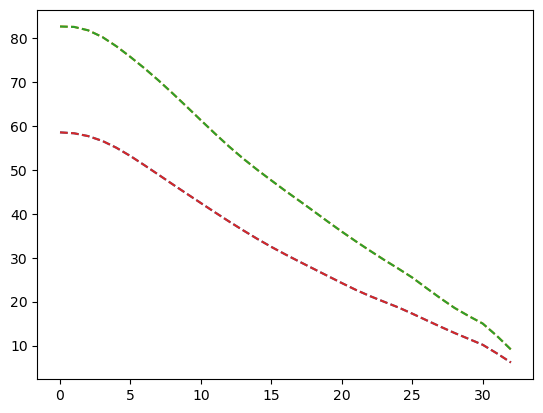

In [35]:
picked_indices = [4, 7, 7,4]

# rot_targets = [12,7,7,12]

for idx in picked_indices:
    plt.plot(all_targets[idx-1], label=f'T{idx}', linestyle='--')

plt.plot(prof33_at_ref_time, label=f'Real', color='k', linewidth=2)
plt.legend()
plt.grid()
plt.title(f"Selected targets to {prof_type} t={ref_time}ms", fontsize=14)


# More complex Code

# Set reference time and num candidates to visualize

In [10]:
ref_time = 1500

#### Step 3. Targets selection

In [11]:
ref_time_idx = np.argmin(np.abs(times - ref_time))  # find the index closest to ref_time
prof33_at_ref_time = convert_profiles_101_to_33(profile_signals[ref_time_idx, :])

# Get three target index so that prof33_at_ref_time is closest to the target
n_candidates = 3
diffs = np.linalg.norm(all_targets - prof33_at_ref_time, axis=1)
ref_target_candidates_idxs = np.argsort(diffs)[:n_candidates]
big_print(f"Candidates for ref target indices: {ref_target_candidates_idxs.tolist()}", size=20)

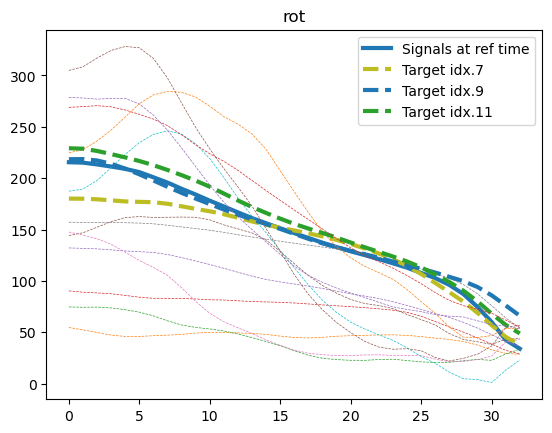

In [12]:
plt.plot(prof33_at_ref_time, label='Signals at ref time', linewidth=3)
for i in range(num_total_targets):
    if i in ref_target_candidates_idxs:
        plt.plot(all_targets[i, :], label=f'Target idx.{i}', linestyle='--', linewidth=3)
    else:
        plt.plot(all_targets[i, :], linestyle='--', linewidth=.5)
plt.title(f'{prof_type}')
plt.legend()
plt.show()

# Set ref target idx (Target1 of next shot)

In [13]:
selected_ref_target_idx = 3

#### Candidates for upper targets

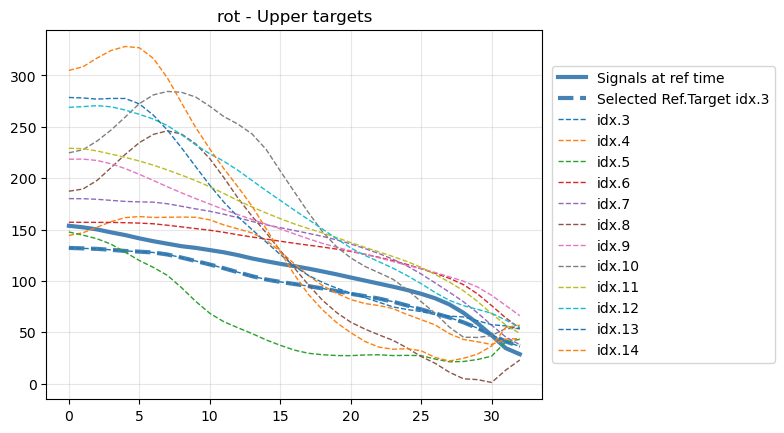

In [14]:
plt.plot(prof33_at_ref_time, label='Signals at ref time', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_ref_target_idx, :], label=f'Selected Ref.Target idx.{selected_ref_target_idx}', linestyle='--', linewidth=3, color='steelblue')
for i in range(selected_ref_target_idx, num_total_targets):
    plt.plot(all_targets[i, :], linestyle='--', linewidth=1, label=f'idx.{i}')
plt.title(f'{prof_type} - Upper targets')
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(alpha=0.3)
plt.show()

# Set upper target index (Target2 for next shot)

In [15]:
selected_upper_target_idx = 9

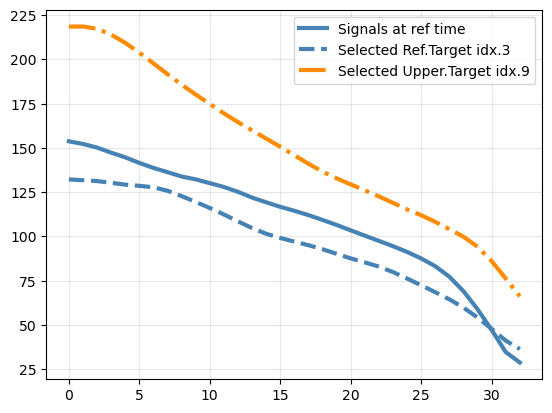

In [16]:
plt.plot(prof33_at_ref_time, label='Signals at ref time', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_ref_target_idx, :], label=f'Selected Ref.Target idx.{selected_ref_target_idx}', linestyle='--', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_upper_target_idx, :], label=f'Selected Upper.Target idx.{selected_upper_target_idx}', linestyle='-.', linewidth=3, color='darkorange')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Candidates for lower targets

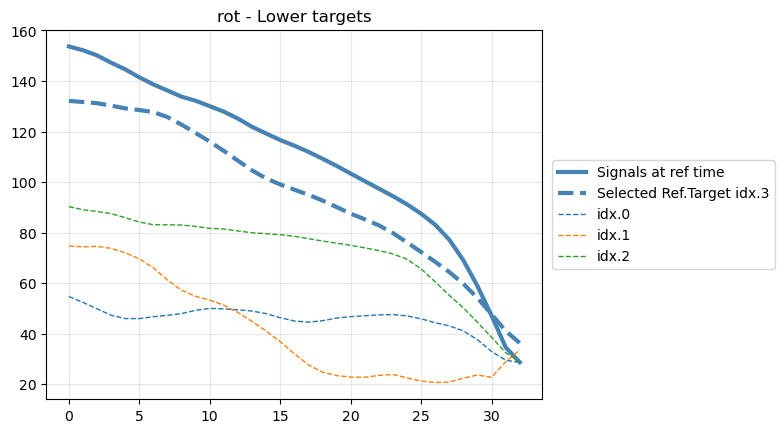

In [17]:
plt.plot(prof33_at_ref_time, label='Signals at ref time', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_ref_target_idx, :], label=f'Selected Ref.Target idx.{selected_ref_target_idx}', linestyle='--', linewidth=3, color='steelblue')
for i in range(selected_ref_target_idx):
    plt.plot(all_targets[i, :], linestyle='--', linewidth=1, label=f'idx.{i}')
plt.title(f'{prof_type} - Lower targets')
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(alpha=0.3)
plt.show()

# Set lower target index (Target3 for next shot)

In [18]:
selected_lower_target_idx = 2

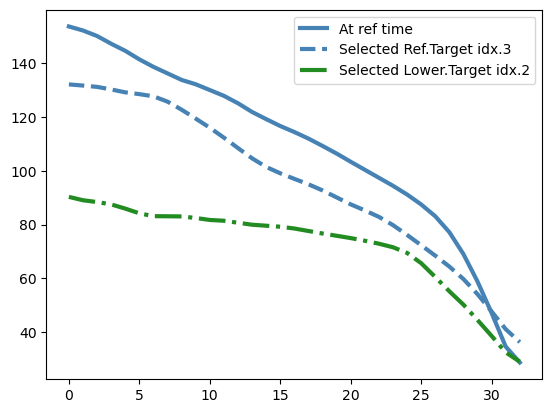

In [19]:
plt.plot(prof33_at_ref_time, label='At ref time', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_ref_target_idx, :], label=f'Selected Ref.Target idx.{selected_ref_target_idx}', linestyle='--', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_lower_target_idx, :], label=f'Selected Lower.Target idx.{selected_lower_target_idx}', linestyle='-.', linewidth=3, color='forestgreen')
plt.legend()
plt.show()

# Summary

In [20]:
print("================= Target selection =================")
print(f"Shot ID: {shot}")
print(f"Profile: {prof_type}")
print(f"Taget 1: index {selected_ref_target_idx}, effective from {targets_set_time[0]} to {targets_set_time[1]} ms")
print(f"Taget 2: index {selected_upper_target_idx}, effective from {targets_set_time[1]} to {targets_set_time[2]} ms")
print(f"Taget 3: index {selected_lower_target_idx}, effective from {targets_set_time[2]} to {targets_set_time[3]} ms")
print(f"Taget 4: index {selected_ref_target_idx}, effective from {targets_set_time[3]} to {targets_set_time[4]} ms")
print("====================================================")

================= Target selection =================
Shot ID: 203023
Profile: rot
Taget 1: index 3, effective from 1500 to 2000 ms
Taget 2: index 9, effective from 2000 to 2500 ms
Taget 3: index 2, effective from 2500 to 3000 ms


IndexError: list index out of range

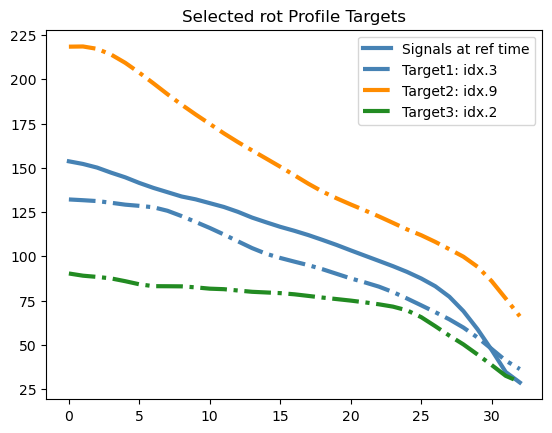

In [70]:
plt.plot(prof33_at_ref_time, label='Signals at ref time', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_ref_target_idx, :], label=f'Target1: idx.{selected_ref_target_idx}', linestyle='-.', linewidth=3, color='steelblue')
plt.plot(all_targets[selected_upper_target_idx, :], label=f'Target2: idx.{selected_upper_target_idx}', linestyle='-.', linewidth=3, color='darkorange')
plt.plot(all_targets[selected_lower_target_idx, :], label=f'Target3: idx.{selected_lower_target_idx}', linestyle='-.', linewidth=3, color='forestgreen')
plt.title(f'Selected {prof_type} Profile Targets')
plt.legend()
plt.show()